In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Build SVM Model
model = SVC(kernel='rbf')
model.fit(X_train, y_train)
# Prediction
y_pred = model.predict(X_test)
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



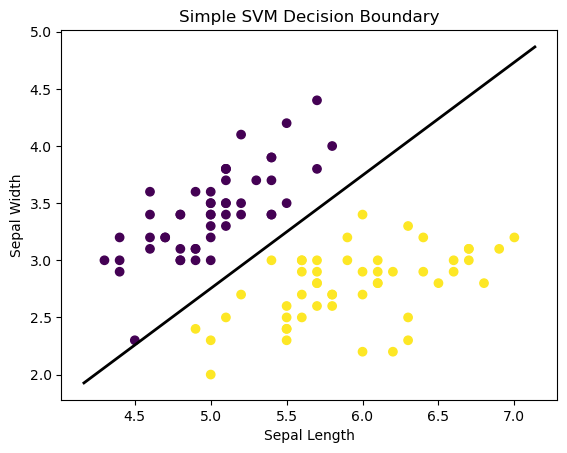

In [2]:
#visualization for 2 features
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
# Load Iris
iris = load_iris()
# Take only Setosa and Versicolor
X = iris.data[:100, :2]   # First 2 features
y = iris.target[:100]     # First 2 classes
# Train SVM
model = SVC(kernel='linear')
model.fit(X, y)
# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y)
# Decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
w = model.coef_[0]
b = model.intercept_[0]
x_points = [xlim[0], xlim[1]]
y_points = -(w[0] * x_points[0] + b) / w[1], -(w[0] * x_points[1] + b) / w[1]
plt.plot(x_points, y_points, 'k-', linewidth=2)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Simple SVM Decision Boundary")
plt.show()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

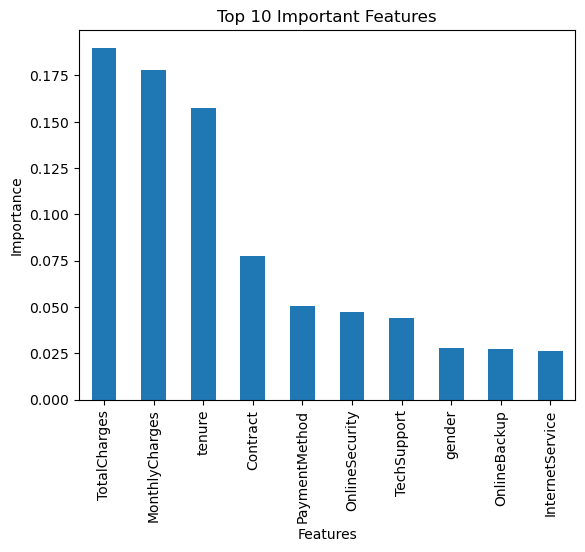

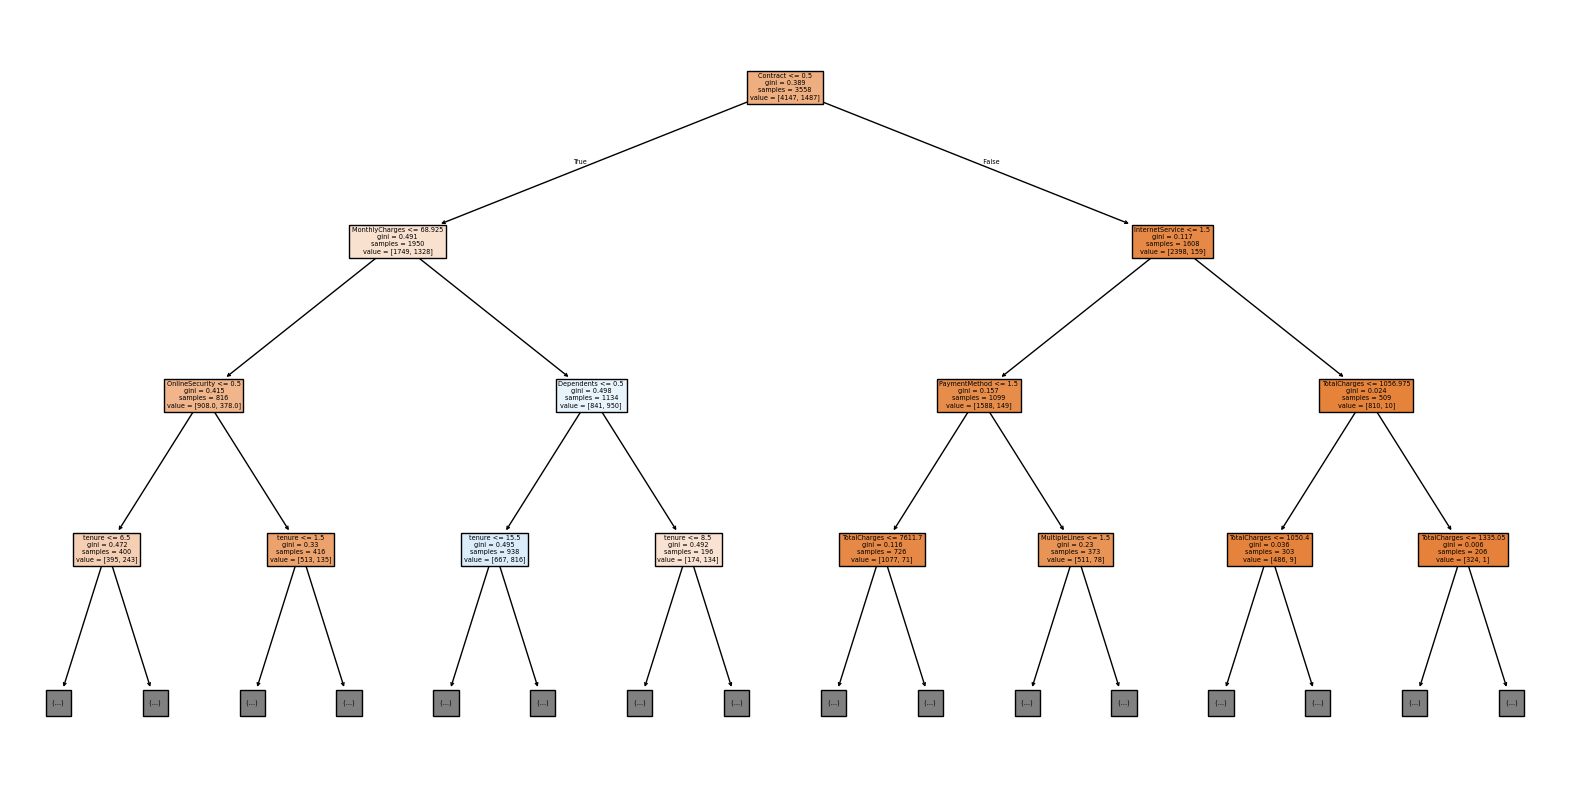

In [10]:
#                                                        *****Random Forest*****
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# 2. Load Dataset
df = pd.read_csv("C:/Users/allad/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# Display basic info
print(df.head())
print(df.info())
# 3. Data Preprocessing
# Drop customerID (not useful)
df.drop("customerID", axis=1, inplace=True)
# Convert TotalCharges to numbers
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# Handle missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
# Convert target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
# Encode categorical variables
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])
# 4. Split Data
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )
# 5. Train Random Forest Model
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train, y_train)
# 6. Predictions
y_pred = model.predict(X_test)
# 7. Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
results = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})
print(results.head(20))  
# 8. Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feat_importance = pd.Series(importances, index=feature_names)
feat_importance = feat_importance.sort_values(ascending=False)
# Plot Feature Importance
plt.figure()
feat_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()
#plotting Random forest
tree = model.estimators_[0]
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True, max_depth=3)
plt.show()



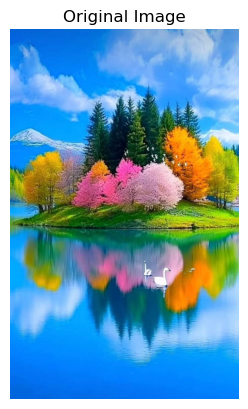

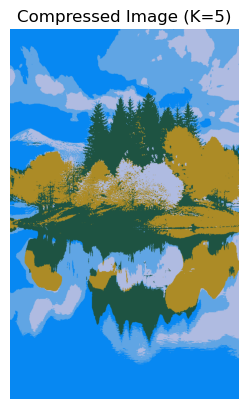

In [8]:
#                                                   *****K-Means Clustering*****
!pip install opencv-python matplotlib scikit-learn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# Load image
image = cv2.imread("C:/Users/allad/Downloads/image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Show original image
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()
# Reshape image
pixel_data = image.reshape((-1, 3))
pixel_data = np.float32(pixel_data)
# Apply KMeans
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixel_data)
# Replace pixels
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
new_image = centroids[labels]
new_image = new_image.reshape(image.shape)
new_image = np.uint8(new_image)
# Show compressed image
plt.imshow(new_image)
plt.title(f"Compressed Image (K={k})")
plt.axis('off')
plt.show()



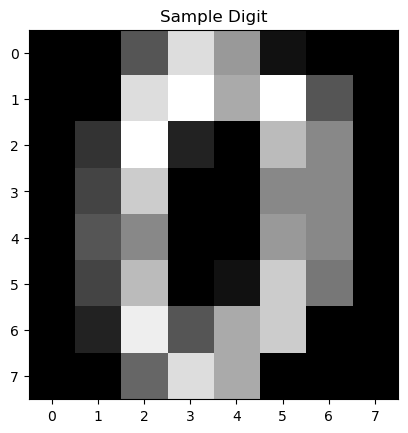

Original shape: (1797, 64)
Reduced shape(After PCA): (1797, 20)


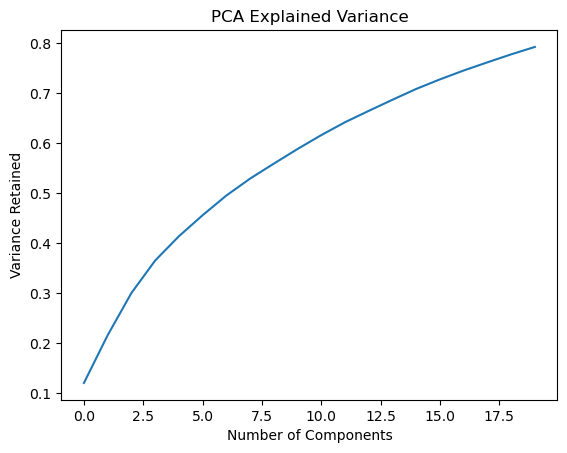

Accuracy after PCA: 0.9416666666666667


In [2]:
#                                                      *****Principal Component Analysis (PCA)*****
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# Step 2: Load dataset
digits = load_digits()
X = digits.data
y = digits.target
# Step 3: Show sample image
plt.imshow(digits.images[0], cmap='gray')
plt.title("Sample Digit")
plt.show()
# Step 4: Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Step 5: Apply PCA
pca = PCA(n_components=20)  # reduce 64 → 20
X_pca = pca.fit_transform(X_scaled)
print("Original shape:", X.shape)
print("Reduced shape(After PCA):", X_pca.shape)
# Step 6: Explained variance plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance Retained')
plt.title('PCA Explained Variance')
plt.show()
# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split( X_pca, y, test_size=0.2, random_state=42)
# Step 8: Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Step 9: Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy after PCA:", accuracy)

In [1]:
#                                                     *****Neural Network (MLP)*****
#Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
# Load data
data = load_iris()
X = data.data
y = data.target
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Scale data (IMPORTANT for MLP)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Build MLP model
model = MLPClassifier(hidden_layer_sizes=(10, 8),activation='relu',max_iter=1000)
# model training
model.fit(X_train, y_train)
# Predicting
y_pred = model.predict(X_test)
print("=== Sample Predictions ===")
for i in range(5):
    print(f"Actual: {y_test[i]} | Predicted: {y_pred[i]}")
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Sample Predictions ===
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 2 | Predicted: 2
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1

Accuracy: 1.0

Confusion Matrix:
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

